Setup

In [ ]:
%%writefile requirements.txt
transformers==4.44.2
datasets==2.21.0
evaluate==0.4.4
accelerate==0.34.2
optuna==3.6.1
scikit-learn==1.5.0
seaborn==0.13.2
matplotlib==3.9.0

In [ ]:
# ── Instala dependências com versões fixadas (não mexe no torch/CUDA já provido pelo
# Kaggle — só fixa os pacotes voláteis instalados via pip) ─────────────────────────────
!pip install -q -r requirements.txt

import os
import time
import json
import numpy as np
import pandas as pd
import torch
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
    set_seed,
)
from datasets import load_dataset
from torchvision.transforms import (
    Compose,
    Resize,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Normalize,
)
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
)

print(f"Torch: {torch.__version__} | CUDA disponível: {torch.cuda.is_available()} | Optuna: {optuna.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Reprodutibilidade e seeds — MESMOS valores usados no mobilenet.ipynb, para que o
# teste de significância estatística consiga parear observações pelo mesmo 'seed'. ──────
SEED = 42
SEEDS_ADICIONAIS = [123, 2024]
set_seed(SEED)

# ── Configuração de dataset — mesma chave/caminho usados no mobilenet.ipynb, para que os
# arquivos de saída fiquem no padrão outputs/{modelo}_{dataset}/ esperado pelas células de
# Tabela Comparativa e Teste de Significância daquele notebook. ────────────────────────
DATASETS = {
    'newdataset': '/kaggle/input/datasets/tiagoudh/newdataset/new_dataset',
    # 'bracol': '/kaggle/input/bracol/',
    # 'rocole': '/kaggle/input/rocole/',
}
DATASET_ATIVO = 'newdataset'

MODELO_NOME  = 'ViT'
NOME_ARQUIVO = f"{MODELO_NOME}_{DATASET_ATIVO}"
OUTPUT_DIR   = os.path.join('outputs', NOME_ARQUIVO)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset ativo: {DATASET_ATIVO}")
print(f"Diretório de saída: {OUTPUT_DIR}")

Carregando dataset

In [6]:
kaggle_data_path = DATASETS[DATASET_ATIVO]
dataset = load_dataset("imagefolder", data_dir=kaggle_data_path)

print(dataset)

sample_image_for_latency_test = dataset['test'][0]['image']

Resolving data files:   0%|          | 0/1905 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/408 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/409 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1905
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 408
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 409
    })
})


Pré-Processamento com augmentation

In [7]:
model_checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = ViTImageProcessor.from_pretrained(model_checkpoint)
norm = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = image_processor.size["height"]

train_transforms = Compose([
    RandomResizedCrop(size, scale=(0.8, 1.0)),
    RandomRotation(degrees=15),
    ColorJitter(brightness=0.2, contrast=0.2),
    RandomHorizontalFlip(),
    ToTensor(),
    norm,
])

val_transforms = Compose([
    RandomResizedCrop(size),
    ToTensor(),
    norm,
])

def apply_train_transforms(examples):
    examples['pixel_values'] = [train_transforms(img.convert("RGB")) for img in examples['image']]
    return examples

def apply_val_transforms(examples):
    examples['pixel_values'] = [val_transforms(img.convert("RGB")) for img in examples['image']]
    return examples

train_dataset = dataset['train'].map(apply_train_transforms, batched=True)
val_dataset = dataset['validation'].map(apply_val_transforms, batched=True)
test_dataset = dataset['test'].map(apply_val_transforms, batched=True)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Map:   0%|          | 0/1905 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

Busca de Hiperparâmetros (Optuna) + Treinamento Multi-Seed (Rigor Estatístico)

In [ ]:
class_names = dataset['train'].features['label'].names
num_labels = len(class_names)

def model_init():
    return ViTForImageClassification.from_pretrained(
        model_checkpoint, num_labels=num_labels,
        id2label={str(i): label for i, label in enumerate(class_names)},
        label2id={label: str(i) for i, label in enumerate(class_names)},
        ignore_mismatched_sizes=True
    )

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


# ── Busca de hiperparâmetros com Optuna (via Trainer.hyperparameter_search) ────────────
# Diferente do mobilenet.ipynb (onde cada trial treina só um classificador leve em cima de
# features congeladas), aqui CADA trial é um fine-tuning real do ViT-base — por isso a
# busca usa poucas épocas e poucos trials, bem menos que o n_trials=60 usado lá. Uma vez
# encontrados os melhores hiperparâmetros, eles são usados no treino final completo (20
# épocas, 3 seeds) na célula seguinte — mesmo padrão "busca barata → treino caro" do
# mobilenet.ipynb.
N_TRIALS_VIT_SEARCH = 10   # reduza se o tempo de GPU do Kaggle for escasso
EPOCAS_BUSCA        = 5

def hp_space_optuna(trial):
    return {
        "learning_rate":                trial.suggest_float("learning_rate", 1e-6, 1e-3, log=True),
        "weight_decay":                 trial.suggest_float("weight_decay", 0.0, 0.3),
        "warmup_ratio":                 trial.suggest_float("warmup_ratio", 0.0, 0.2),
        "per_device_train_batch_size":  trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
    }

def compute_objective_optuna(metrics):
    # Trainer prefixa as métricas de compute_metrics com "eval_" (eval_f1, eval_accuracy, ...)
    return metrics["eval_f1"]

search_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "optuna_search"),
    report_to="none",
    num_train_epochs=EPOCAS_BUSCA,
    per_device_train_batch_size=8,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="no",          # não salva checkpoint por trial — evitaria explosão de disco
    load_best_model_at_end=False,  # incompatível com save_strategy="no"
    seed=SEED,
    disable_tqdm=True,
)

search_trainer = Trainer(
    model_init=model_init,
    args=search_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f"Iniciando busca de hiperparâmetros com Optuna ({N_TRIALS_VIT_SEARCH} trials, {EPOCAS_BUSCA} épocas cada)...")
best_run = search_trainer.hyperparameter_search(
    hp_space=hp_space_optuna,
    compute_objective=compute_objective_optuna,
    n_trials=N_TRIALS_VIT_SEARCH,
    direction="maximize",
    backend="optuna",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

best_params_vit = best_run.hyperparameters
print(f"\nMelhores hiperparâmetros encontrados: {best_params_vit}")
print(f"Melhor F1-Macro (busca, val): {best_run.objective:.4f}")

with open(os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json'), 'w') as f:
    json.dump(best_params_vit, f, indent=2)
print(f"Melhores parâmetros salvos em: {os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json')}")

Treinamento Definitivo Multi-Seed

In [ ]:
def treinar_com_seed(seed, best_params):
    """
    Faz o fine-tuning do ViT a partir do checkpoint pré-treinado, usando os melhores
    hiperparâmetros encontrados pelo Optuna (best_params_vit) e uma seed específica.
    Retorna (trainer, training_args, métricas de teste) no MESMO formato de métricas usado
    pelo mobilenet.ipynb (accuracy, f1_macro, precision_macro, recall_macro), para permitir
    a comparação estatística entre os dois notebooks via outputs/*/multiseed_*.csv.
    """
    set_seed(seed)

    training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, f"vit_seed{seed}"),
        report_to="none",
        num_train_epochs=20,
        learning_rate=best_params['learning_rate'],
        per_device_train_batch_size=best_params['per_device_train_batch_size'],
        weight_decay=best_params['weight_decay'],
        warmup_ratio=best_params['warmup_ratio'],
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        seed=seed,
    )

    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        # Encerra o treino se o F1 de validação não melhorar por 3 avaliações seguidas —
        # equivalente ao EarlyStopping(patience=15 em épocas de callback) do mobilenet.ipynb,
        # adaptado à escala de 20 épocas do ViT.
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()

    resultado_teste = trainer.predict(test_dataset)
    y_true_seed = resultado_teste.label_ids
    y_pred_seed = resultado_teste.predictions.argmax(axis=1)
    precision_s, recall_s, f1_s, _ = precision_recall_fscore_support(
        y_true_seed, y_pred_seed, average='macro', zero_division=0
    )
    metricas = {
        'seed':            seed,
        'accuracy':        accuracy_score(y_true_seed, y_pred_seed),
        'f1_macro':        f1_s,
        'precision_macro': precision_s,
        'recall_macro':    recall_s,
    }
    return trainer, training_args, metricas


# Treina com a seed canônica (42) e com as seeds adicionais — os MESMOS valores usados no
# mobilenet.ipynb — para permitir o pareamento por seed no teste de significância
# estatística entre modelos. Atenção: são 3 fine-tunings completos do ViT-base (até 20
# épocas cada, com early stopping), o que pode levar bem mais de 1h no total dependendo da
# GPU do Kaggle.
resultados_multiseed  = []
final_trainer         = None
final_training_args   = None

for seed in [SEED] + SEEDS_ADICIONAIS:
    print(f"\n{'=' * 80}\nTreinando ViT com seed={seed}\n{'=' * 80}")
    trainer_seed, args_seed, metricas_seed = treinar_com_seed(seed, best_params_vit)
    resultados_multiseed.append(metricas_seed)
    print(f"  seed={seed} -> Acurácia={metricas_seed['accuracy']:.4f} | F1-Macro={metricas_seed['f1_macro']:.4f}")

    # Mantém o modelo da seed canônica (42) para as células de matriz de confusão,
    # latência e exportação PyTorch Mobile mais abaixo.
    if seed == SEED:
        final_trainer       = trainer_seed
        final_training_args = args_seed

df_multiseed = pd.DataFrame(resultados_multiseed)
print("\n── Resultados por seed (ViT) ──")
print(df_multiseed.to_string(index=False))

media_multiseed  = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].mean()
desvio_multiseed = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].std()
print(f"\n── Média ± Desvio-padrão ({len(df_multiseed)} seeds) ──")
for col in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    print(f"  {col:17s}: {media_multiseed[col]:.4f} ± {desvio_multiseed[col]:.4f}")

# Persiste no MESMO formato lido pelas células de Tabela Comparativa e Teste de
# Significância Estatística do mobilenet.ipynb (glob por outputs/*/multiseed_*.csv).
df_multiseed_export = df_multiseed.copy()
df_multiseed_export.insert(0, 'dataset', DATASET_ATIVO)
df_multiseed_export.insert(0, 'modelo', MODELO_NOME)
multiseed_path = os.path.join(OUTPUT_DIR, f'multiseed_{NOME_ARQUIVO}.csv')
df_multiseed_export.to_csv(multiseed_path, index=False)
print(f"\nResultados por seed salvos em: {multiseed_path}")
print("Copie a pasta 'outputs/' (ou seu conteúdo) para o mesmo diretório do mobilenet.ipynb "
      "para que o ViT apareça na Tabela Comparativa e no Teste de Significância Estatística.")

# Torna o modelo da seed canônica (42) disponível para as células seguintes deste notebook.
final_trainer.save_model()
image_processor.save_pretrained(final_training_args.output_dir)

Métricas do Modelo Canônico (seed=42)

In [9]:
# As métricas de teste do modelo canônico (seed=42) já foram calculadas na célula de
# treinamento multi-seed acima (resultados_multiseed[0]) — aqui só exibimos o eval_loss
# do HF Trainer como complemento.
test_metrics_hf = final_trainer.evaluate(test_dataset)
print(test_metrics_hf)

metricas_canonicas = resultados_multiseed[0]
print(f"\nModelo canônico (seed={metricas_canonicas['seed']}):")
print(f"  Acurácia        : {metricas_canonicas['accuracy']:.4f}")
print(f"  F1-Macro        : {metricas_canonicas['f1_macro']:.4f}")
print(f"  Precision-Macro : {metricas_canonicas['precision_macro']:.4f}")
print(f"  Recall-Macro    : {metricas_canonicas['recall_macro']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.21590584516525269, 'eval_accuracy': 0.941320293398533, 'eval_f1': 0.932935181630118, 'eval_precision': 0.9273504889333051, 'eval_recall': 0.9394028023077828, 'eval_runtime': 37.909, 'eval_samples_per_second': 10.789, 'eval_steps_per_second': 0.686, 'epoch': 20.0}

Modelo canônico (seed=42):
  Acurácia        : 0.9413
  F1-Macro        : 0.9329
  Precision-Macro : 0.9274
  Recall-Macro    : 0.9394


Matriz de Confusão (Modelo Canônico, seed=42)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


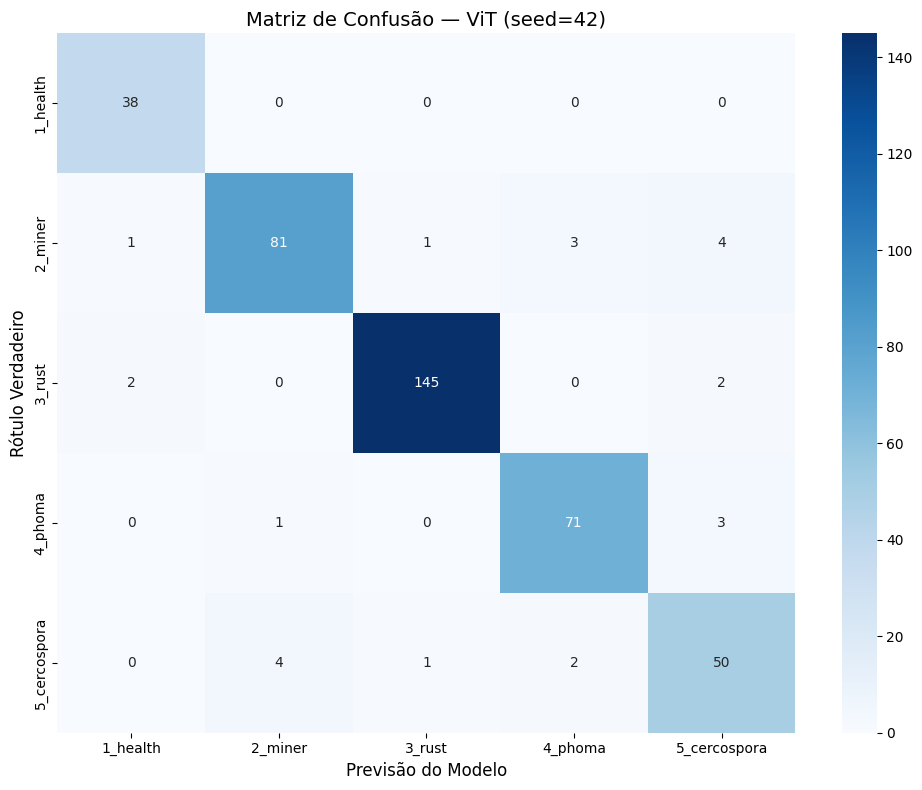

In [10]:
results = final_trainer.predict(test_dataset)
y_true = results.label_ids
y_pred = results.predictions.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Previsão do Modelo", fontsize=12)
plt.ylabel("Rótulo Verdadeiro", fontsize=12)
plt.title("Matriz de Confusão — ViT (seed=42)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'matriz_confusao_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()

XAI — Attention Rollout (equivalente ao Grad-CAM para Vision Transformers)

In [ ]:
def attention_rollout(model, pixel_values, discard_ratio=0.1, head_fusion="mean"):
    """
    Attention Rollout (Abnar & Zuidema, 2020) — agrega os mapas de atenção de TODAS as
    camadas do ViT num único heatmap, propagando a atenção do token [CLS] até os patches de
    entrada através das conexões residuais. É o equivalente funcional ao Grad-CAM (usado
    nos backbones CNN do mobilenet.ipynb) para arquiteturas baseadas em atenção — o ViT não
    tem mapas de características convolucionais para retropropagar gradientes, então o
    Grad-CAM tradicional simplesmente não se aplica aqui.
    """
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)
    attentions = outputs.attentions  # tupla de (1, n_heads, seq_len, seq_len), uma por camada

    seq_len = attentions[0].size(-1)
    result = torch.eye(seq_len, device=pixel_values.device)

    for attention in attentions:
        if head_fusion == "mean":
            fused = attention.mean(dim=1)[0]
        elif head_fusion == "max":
            fused = attention.max(dim=1)[0][0]
        else:
            fused = attention.min(dim=1)[0][0]

        # Descarta os "discard_ratio" tokens de menor atenção por camada, reduzindo o ruído
        # de fundo que o rollout tende a acumular (prática comum na literatura de Attention
        # Rollout).
        if discard_ratio > 0:
            flat = fused.view(-1)
            n_descartar = int(flat.size(0) * discard_ratio)
            if n_descartar > 0:
                _, idx = flat.topk(n_descartar, largest=False)
                flat[idx] = 0
            fused = flat.view(fused.size())

        identidade = torch.eye(seq_len, device=pixel_values.device)
        a = (fused + identidade) / 2
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result

    # Atenção do token [CLS] (índice 0) para cada patch (índices 1..N)
    mask = result[0, 1:].cpu().numpy()
    grid_size = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(grid_size, grid_size)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask


def gerar_overlay_attention(img_rgb, mask, alpha=0.45):
    """Sobrepõe o heatmap do Attention Rollout à imagem original — mesmo estilo visual do
    Grad-CAM do mobilenet.ipynb, via PIL/matplotlib para não adicionar a dependência do
    OpenCV neste notebook."""
    h, w = img_rgb.shape[:2]
    mask_img = Image.fromarray(np.uint8(255 * mask)).resize((w, h), Image.BILINEAR)
    mask_resized = np.array(mask_img).astype(np.float32) / 255.0
    jet_colors = plt.colormaps.get_cmap("jet")(np.arange(256))[:, :3]
    heat_rgb = jet_colors[np.uint8(255 * mask_resized)]
    overlay = heat_rgb * alpha + img_rgb.astype(np.float32) / 255 * (1 - alpha)
    return np.clip(overlay, 0, 1)


# Transformação determinística (sem RandomResizedCrop) só para as imagens exibidas nos
# heatmaps — garante que a mesma amostra sempre gere a mesma visualização, diferente do
# val_transforms usado na avaliação (que ainda tem RandomResizedCrop residual do código
# original da IC).
display_transform = Compose([
    Resize((size, size)),
    ToTensor(),
    norm,
])

N_POR_CLASSE_ATTN = 3
modelo_canonico = final_trainer.model.to(device)

print("Gerando explicações via Attention Rollout por classe...")
for class_idx, class_name in enumerate(class_names):
    indices_acerto = [i for i in range(len(y_true)) if y_true[i] == class_idx and y_pred[i] == class_idx]
    amostras = indices_acerto[:N_POR_CLASSE_ATTN]
    if not amostras:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 5))
    if len(amostras) == 1:
        axes = [axes]

    for col, idx in enumerate(amostras):
        img_pil = dataset['test'][idx]['image'].convert("RGB")
        pixel_values = display_transform(img_pil).unsqueeze(0).to(device)
        img_rgb = np.array(img_pil.resize((size, size)))

        mask = attention_rollout(modelo_canonico, pixel_values)
        overlay = gerar_overlay_attention(img_rgb, mask)

        axes[col].imshow(overlay)
        axes[col].set_title(f"{class_name} — amostra {col + 1}", fontsize=10)
        axes[col].axis('off')

    plt.suptitle(f'Attention Rollout — ViT — Classe: {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'attention_rollout_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  [{class_name}] OK")

Latência (Modelo Canônico, seed=42)

In [ ]:
# Benchmark "cru" (forward pass direto, sem o wrapper pipeline()) — a mesma metodologia
# usada no mobilenet.ipynb para o modelo Keras em memória (warmup + 100 execuções + média/
# desvio-padrão/p95), para que a comparação de latência entre ViT e as CNNs seja justa. O
# pipeline() embutia pré/pós-processamento e overhead do Python que não é comparável ao
# benchmark "puro" do outro notebook.
final_model_path = final_training_args.output_dir
model_eager = final_trainer.model.to(device)
model_eager.eval()

N_WARMUP = 10
N_RUNS   = 100

sample_pixel_values = display_transform(sample_image_for_latency_test.convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    for _ in range(N_WARMUP):
        _ = model_eager(sample_pixel_values)

tempos = []
with torch.no_grad():
    for _ in range(N_RUNS):
        if device.type == "cuda":
            torch.cuda.synchronize()  # CUDA é assíncrono — sem isso, mediríamos só o tempo de "disparo" do kernel
        t0 = time.perf_counter()
        _ = model_eager(sample_pixel_values)
        if device.type == "cuda":
            torch.cuda.synchronize()
        tempos.append((time.perf_counter() - t0) * 1000)

latencia_media = np.mean(tempos)
latencia_std   = np.std(tempos)
latencia_p95   = np.percentile(tempos, 95)

print(f"── Benchmark de Inferência (PyTorch Eager, {device.type.upper()}, modelo canônico seed=42) ──")
print(f"  Latência média  : {latencia_media:.2f} ms")
print(f"  Desvio padrão   : {latencia_std:.2f} ms")
print(f"  Percentil 95    : {latencia_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / latencia_media:.1f} imagens/s")

Exportando modelo (PyTorch Mobile, Modelo Canônico)

In [12]:
try:
    export_model = ViTForImageClassification.from_pretrained(final_model_path)
    
    class ViTWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            return self.model(x).logits

    wrapper_model = ViTWrapper(export_model)
    wrapper_model.eval()
    
    example_input = torch.randn(1, 3, 224, 224)
    traced_model = torch.jit.trace(wrapper_model, example_input)
    
    from torch.utils.mobile_optimizer import optimize_for_mobile
    optimized_model = optimize_for_mobile(traced_model)
    
    ptl_path = os.path.join(final_model_path, f"{NOME_ARQUIVO}.ptl")
    optimized_model._save_for_lite_interpreter(ptl_path)
    print(f"✅ Modelo PyTorch Mobile final salvo com sucesso em: {ptl_path}")

except Exception as e:
    print(f"❌ Erro ao converter para PyTorch Mobile: {e}")

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:4713: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/vit/modeling_vit.py:163: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if num_channels != self.num_channels:
/usr/local/lib/python3.12/dist-packages/transformers/models/vit/modeling_vit.py:169: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if height != 

✅ Modelo PyTorch Mobile final salvo com sucesso em: outputs/ViT_newdataset/vit_seed42/ViT_newdataset.ptl


/tmp/ipykernel_58/1479088916.py:21: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model._save_for_lite_interpreter(ptl_path)


Latência (Modelo Exportado — PyTorch Mobile, CPU)

In [ ]:
# Benchmarka o modelo REALMENTE exportado (.ptl), do mesmo jeito que o mobilenet.ipynb faz
# com o TFLite: carrega o artefato do disco e mede em CPU (o cenário real de inferência
# offline no celular), separado do benchmark "Eager" acima (que roda em GPU, se disponível).
from torch.jit.mobile import _load_for_lite_interpreter

mobile_model = _load_for_lite_interpreter(ptl_path)
input_ptl = sample_pixel_values.detach().cpu()

for _ in range(N_WARMUP):
    _ = mobile_model(input_ptl)

tempos_mobile = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _ = mobile_model(input_ptl)
    tempos_mobile.append((time.perf_counter() - t0) * 1000)

lat_mobile_media = np.mean(tempos_mobile)
lat_mobile_std   = np.std(tempos_mobile)
lat_mobile_p95   = np.percentile(tempos_mobile, 95)
ptl_size_mb      = os.path.getsize(ptl_path) / (1024 ** 2)

print("── Benchmark de Inferência (PyTorch Mobile / .ptl, CPU) ──")
print(f"  Latência média  : {lat_mobile_media:.2f} ms")
print(f"  Desvio padrão   : {lat_mobile_std:.2f} ms")
print(f"  Percentil 95    : {lat_mobile_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / lat_mobile_media:.1f} imagens/s")
print(f"  Tamanho do modelo (.ptl): {ptl_size_mb:.2f} MB")
print(f"\nNota: a comparação com a latência 'Eager' acima não é 1:1 — aquele benchmark roda em "
      f"{device.type.upper()}, enquanto este (.ptl) é sempre avaliado em CPU, simulando o "
      f"cenário real de inferência offline no celular (o mesmo motivo pelo qual o "
      f"mobilenet.ipynb reporta Keras e TFLite separadamente, em vez de um único número).")

Linha-Resumo para a Tabela Comparativa (Modelos x Datasets)

In [ ]:
# Constroi uma linha-resumo no MESMO formato/nomes de coluna usados pelo resultados_comparativos
# do mobilenet.ipynb (Modelo, Dataset, medias/desvios multi-seed, N_seeds, latencia em
# memoria/exportado, tamanho exportado) para que as duas tabelas sejam concatenaveis com um
# simples pd.concat, formando a matriz Dataset x Modelo completa (CNNs + ViT).
resultados_comparativos_vit = [{
    'Modelo':                    MODELO_NOME,
    'Dataset':                   DATASET_ATIVO,
    'Acurácia (méd)':            round(media_multiseed['accuracy'], 4),
    'Acurácia (dp)':             round(desvio_multiseed['accuracy'], 4),
    'F1-Macro (méd)':            round(media_multiseed['f1_macro'], 4),
    'F1-Macro (dp)':             round(desvio_multiseed['f1_macro'], 4),
    'Precision-Macro (méd)':     round(media_multiseed['precision_macro'], 4),
    'Recall-Macro (méd)':        round(media_multiseed['recall_macro'], 4),
    'N_seeds':                   len(df_multiseed),
    'Lat. Em Memória (ms)':      round(latencia_media, 2),
    'Lat. Exportado (ms)':       round(lat_mobile_media, 2),
    'Tamanho Exportado (MB)':    round(ptl_size_mb, 2),
    'Formato Exportado':         'PyTorch Mobile (.ptl)',
}]

df_comparativo_vit = pd.DataFrame(resultados_comparativos_vit)
print("=" * 90)
print("  LINHA COMPARATIVA — ViT")
print("=" * 90)
print(df_comparativo_vit.to_string(index=False))
print("=" * 90)

comparativo_path = os.path.join(OUTPUT_DIR, f'resultados_comparativos_{NOME_ARQUIVO}.csv')
df_comparativo_vit.to_csv(comparativo_path, index=False)
print(f"Linha salva em: {comparativo_path}")
print("Copie a pasta 'outputs/' para o mesmo diretório do mobilenet.ipynb. Os nomes de coluna")
print("são IDÊNTICOS aos de resultados_comparativos do mobilenet.ipynb, de propósito — basta")
print("pd.concat([df_comp, df_comparativo_vit], ignore_index=True) para juntar as duas tabelas")
print("numa única matriz Dataset × Modelo (CNNs + ViT).")
